In [28]:
import os
os.environ["KERAS_BACKEND"] = "tensorflow"

from pathlib import Path
import sys
import json

import numpy as np
import matplotlib.pyplot as plt
import keras
import bayesflow as bf


def find_project_root(start=Path.cwd()):
    for path in (start, *start.parents):
        if (path / "pyproject.toml").exists():
            return path
    raise FileNotFoundError("Could not find project root.")


PROJECT_ROOT = find_project_root()

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))


from examples.gaussian.config import ASSUMED_MODELS, MODEL_SPECS
from examples.gaussian.approximators.config import (
    TrainingConfig,
    checkpoint_path,
    history_path,
)
from examples.gaussian.approximators.indirect import (
    build_workflow as build_indirect_workflow,
)
from examples.gaussian.approximators.direct import (
    build_workflow as build_direct_workflow,
)

In [29]:
def load_history(path):
    with open(path, "r", encoding="utf-8") as f:
        saved = json.load(f)

    history = keras.callbacks.History()
    history.history = saved["history"]

    n_epochs = len(history.history["loss"])
    history.epoch = list(range(n_epochs))

    return history

In [30]:
MODEL = "m3"
NUM_OBS = 100
SUMMARY_DIM = 20

In [31]:
config = TrainingConfig(
    num_dims=20,
    num_obs=NUM_OBS,
    summary_dim=SUMMARY_DIM,
    epochs=256,
    batch_size=64,
    num_batches=128,
    learning_rate=1e-4,
    seed=2025,
    summary_base_distribution="normal",
)

network_path = checkpoint_path(
    config,
    model=MODEL,
)

hist_path = history_path(
    config,
    model=MODEL,
)

print("Network:", network_path)
print("History:", hist_path)

Network: /Users/yimingzang/Documents/Project/model_comparison/examples/gaussian/networks/m3_n100_s20_mmd.keras
History: /Users/yimingzang/Documents/Project/model_comparison/examples/gaussian/networks/history/m3_n100_s20_mmd.json


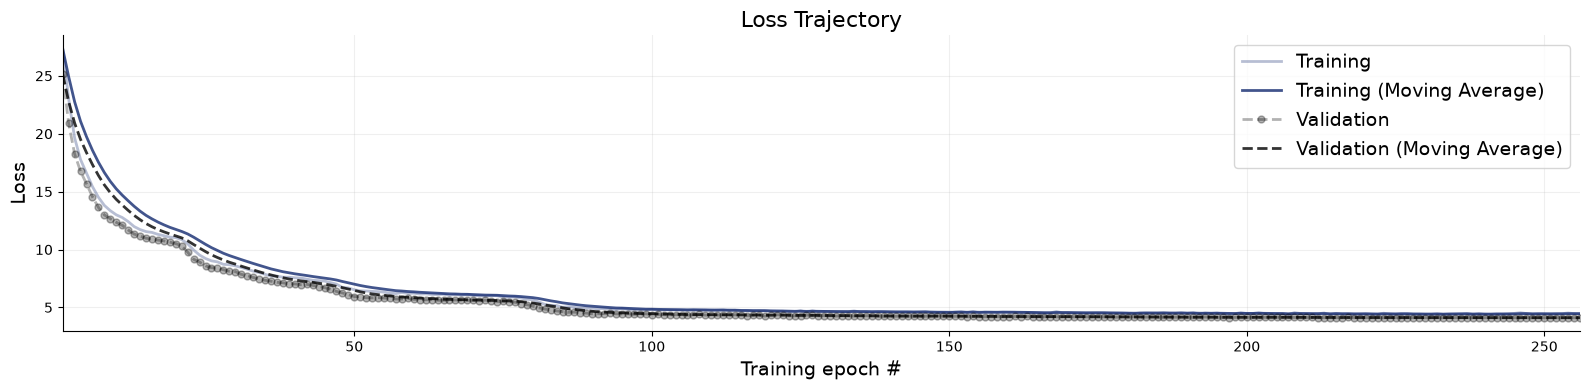

In [32]:
history = load_history(hist_path)

f = bf.diagnostics.plots.loss(history)
plt.show()

In [33]:
workflow = build_indirect_workflow(
    model=MODEL,
    config=config,
)

workflow.load_approximator(
    path=network_path,
)

print("Loaded:", network_path)

INFO:bayesflow:Approximator restored from '/Users/yimingzang/Documents/Project/model_comparison/examples/gaussian/networks/m3_n100_s20_mmd.keras'.


Loaded: /Users/yimingzang/Documents/Project/model_comparison/examples/gaussian/networks/m3_n100_s20_mmd.keras


In [34]:
NUM_TEST_DATASETS = 200
NUM_POSTERIOR_SAMPLES = 1000

val_sims = workflow.simulate(NUM_TEST_DATASETS)

post_draws = workflow.sample(
    conditions=val_sims,
    num_samples=NUM_POSTERIOR_SAMPLES,
)

print("Validation keys:")
print(val_sims.keys())

print("\nPosterior draw keys:")
print(post_draws.keys())

Summarizing:   0%|          | 0/1 [00:00<?, ?batch/s]

Sampling:   0%|          | 0/1 [00:00<?, ?batch/s]

INFO:bayesflow:Sampling completed in 0.94 seconds.


Validation keys:
dict_keys(['mu', 'x'])

Posterior draw keys:
dict_keys(['mu'])


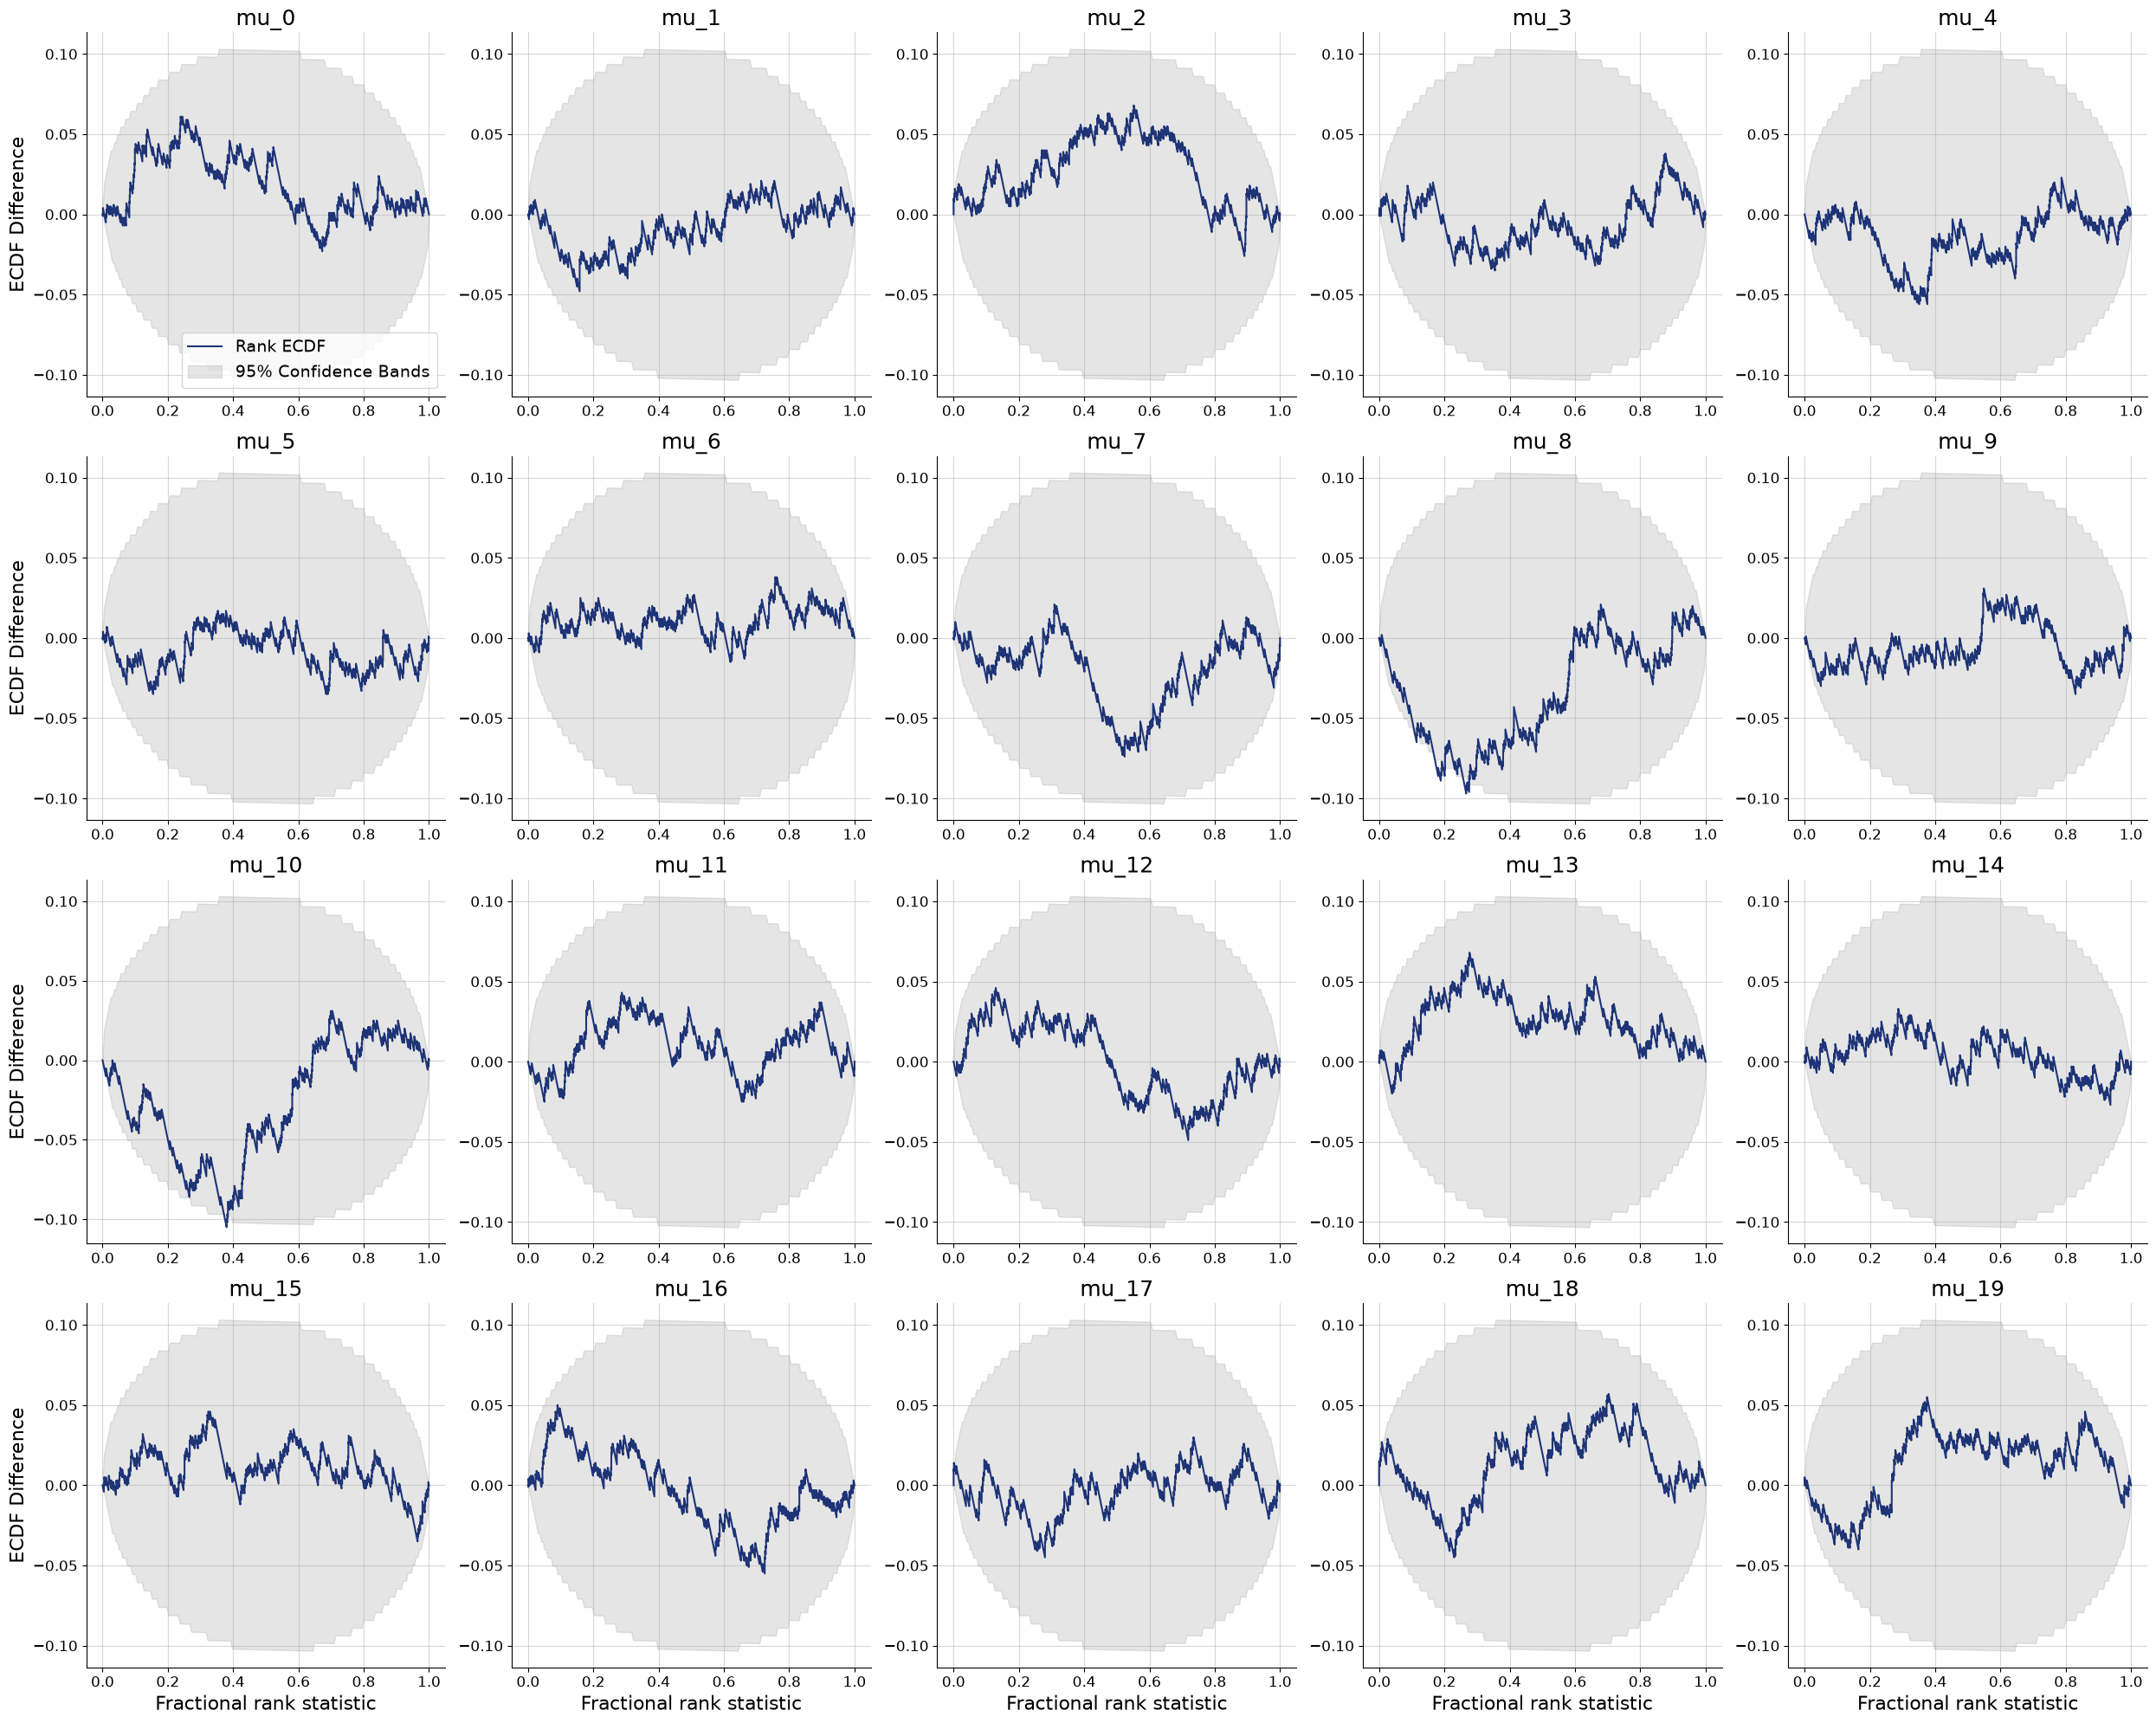

In [35]:
f2 = bf.diagnostics.plots.calibration_ecdf(
    post_draws,
    val_sims,
    difference=True,
)

plt.show()

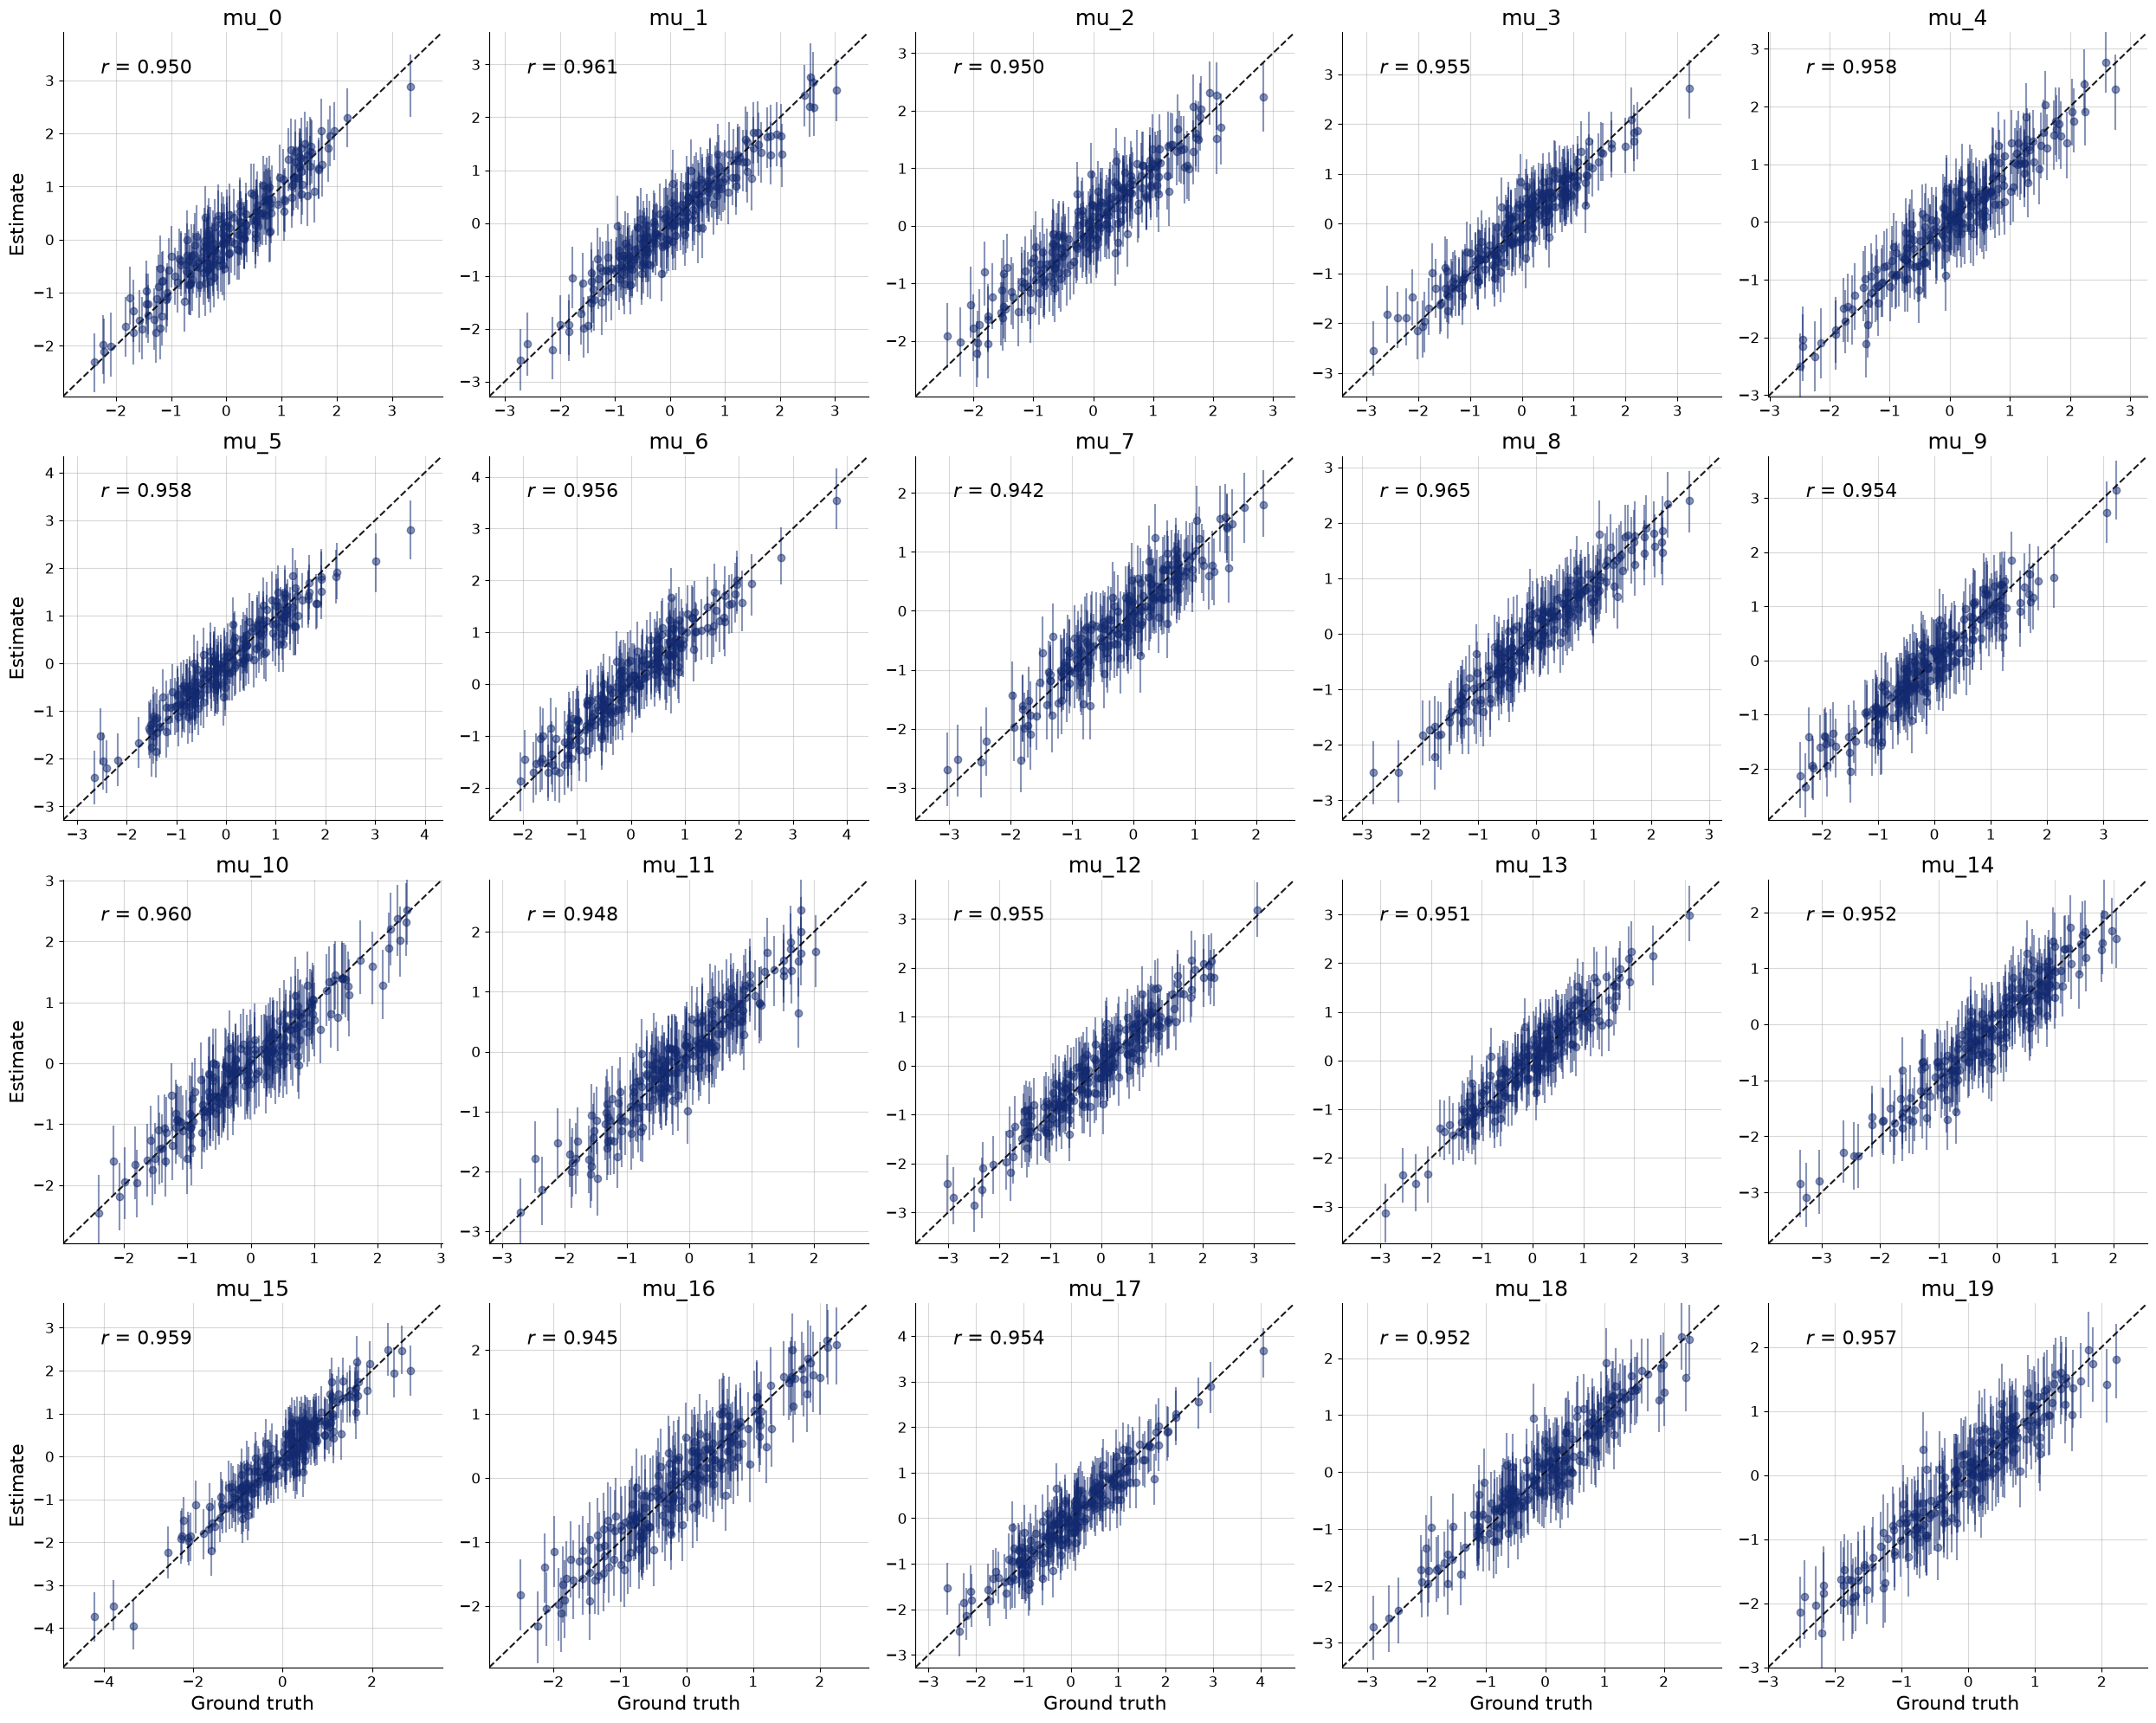

In [36]:
f3 = bf.diagnostics.plots.recovery(
    post_draws,
    val_sims,
)

plt.show()